# fiber-mosaic quickstart

Build per-color fiber photometry recordings, read fluorescence with the fiber-native API, and bundle multiple colors into a single experiment handle.

Layering used by the library:

- **fiber** &rarr; one channel of a recording
- **color** &rarr; one `BaseFiberPhotometryExtractor` (each color has its own timebase)
- **experiment** &rarr; one `FiberPhotometryRecordingGroup` holding all colors

In [1]:
# matplotlib is only needed for the plotting cell below
# %pip install matplotlib

import numpy as np
from spikeinterface.core.numpyextractors import NumpyRecordingSegment

from fiber_mosaic import (
    BaseFiberPhotometryExtractor,
    FiberPhotometryRecordingGroup,
)

## 1. Synthesize a single-color recording

Three fibers, 5 seconds at 100 Hz. In a real experiment the array would come from your acquisition file via a subclass of `BaseFiberPhotometryFileExtractor`.

In [2]:
sampling_rate = 100.0  # Hz
n_samples = 500
fiber_ids = ["fiber_1", "fiber_2", "fiber_3"]

t = np.arange(n_samples) / sampling_rate
rng = np.random.default_rng(0)

green_traces = np.column_stack(
    [
        1.0 + 0.20 * np.sin(2 * np.pi * 0.5 * t),
        1.0 + 0.30 * np.sin(2 * np.pi * 0.8 * t + 1.0),
        1.0 + 0.10 * np.sin(2 * np.pi * 1.2 * t + 2.0),
    ]
).astype("float32")
green_traces += 0.02 * rng.standard_normal(green_traces.shape).astype(
    "float32"
)
green_traces.shape

(500, 3)

## 2. Wrap the array in a segment, attach to a recording

The recording owns metadata (fiber IDs, color, sampling rate). The segment owns the actual numpy array. We reuse spikeinterface's `NumpyRecordingSegment` directly &mdash; `add_segment` wires them together, and you can attach more than one segment for multi-block experiments.

In [3]:
green_rec = BaseFiberPhotometryExtractor(
    sampling_frequency=sampling_rate,
    fiber_ids=fiber_ids,
    color="green",
    dtype="float32",
)

green_seg = NumpyRecordingSegment(
    traces=green_traces,
    sampling_frequency=sampling_rate,
    t_start=None,
)
green_rec.add_segment(green_seg)

green_rec

BaseFiberPhotometryExtractor | color=green | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32

## 3. Read fluorescence

`get_fluorescence` is the fiber-photometry-native API. It accepts `segment_index`, `start_frame`, `end_frame`, and `fiber_ids` &mdash; no ephys-only flags like `return_in_uV`. Internally it delegates to spikeinterface's `get_traces`, so saving, slicing, and concatenation still work.

In [4]:
# all fibers, full segment -> (n_samples, n_fibers)
all_traces = green_rec.get_fluorescence()
all_traces.shape

(500, 3)

In [5]:
# subset of fibers by ID
fiber_3_only = green_rec.get_fluorescence(fiber_ids=["fiber_3"])
fiber_3_only.shape

(500, 1)

In [6]:
# first second of data, all fibers
first_second = green_rec.get_fluorescence(start_frame=0, end_frame=100)
first_second.shape

(100, 3)

## 4. Plot

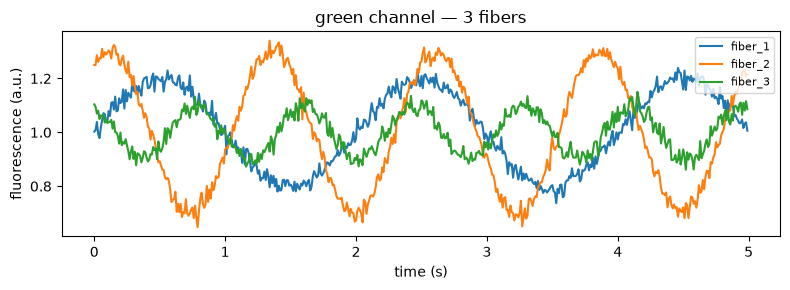

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
for i, fid in enumerate(green_rec.fiber_ids):
    ax.plot(t, all_traces[:, i], label=fid)
ax.set_xlabel("time (s)")
ax.set_ylabel("fluorescence (a.u.)")
ax.set_title(
    f"{green_rec.color} channel \u2014 {green_rec.get_num_fibers()} fibers"
)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

## 5. Multi-color experiments

A real fiber photometry session usually records several colors from the same fibers &mdash; e.g. a calcium indicator (green) plus an isosbestic control (415 nm). Each color is its own recording with its own timebase. `FiberPhotometryRecordingGroup` bundles them and validates that they share the same fibers in the same order.

In [8]:
iso_traces = (
    1.0
    + 0.05 * np.sin(2 * np.pi * 0.3 * t)[:, None]
    + 0.02 * rng.standard_normal((n_samples, 3))
).astype("float32")

iso_rec = BaseFiberPhotometryExtractor(
    sampling_frequency=sampling_rate,
    fiber_ids=fiber_ids,
    color="iso",
    dtype="float32",
)
iso_rec.add_segment(
    NumpyRecordingSegment(
        traces=iso_traces,
        sampling_frequency=sampling_rate,
        t_start=None,
    )
)

experiment = FiberPhotometryRecordingGroup(
    {"green": green_rec, "iso": iso_rec}
)
experiment

FiberPhotometryRecordingGroup | 3 fiber(s), 2 color(s)
  [green] BaseFiberPhotometryExtractor | color=green | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32
  [iso] BaseFiberPhotometryExtractor | color=iso | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32

## 6. Group access patterns

In [9]:
experiment.colors, experiment.fiber_ids, experiment.get_num_fibers()

(['green', 'iso'], array(['fiber_1', 'fiber_2', 'fiber_3'], dtype='<U7'), 3)

In [10]:
# index by color, then call the per-color API
experiment["green"].get_fluorescence(fiber_ids=["fiber_3"]).shape

(500, 1)

In [11]:
# iterate over colors
for color, rec in experiment.items():
    print(f"{color:>6}: {rec.get_fluorescence().shape}")

 green: (500, 3)
   iso: (500, 3)


## 7. Mismatched fibers fail loudly

The group enforces that every color shares the same fibers in the same order &mdash; downstream operations like dF/F or motion regression silently rely on this.

In [12]:
bad = BaseFiberPhotometryExtractor(
    sampling_frequency=sampling_rate,
    fiber_ids=["fiber_1", "fiber_2"],  # missing NAc
    color="red",
    dtype="float32",
)
bad.add_segment(
    NumpyRecordingSegment(
        traces=np.zeros((n_samples, 2), dtype="float32"),
        sampling_frequency=sampling_rate,
        t_start=None,
    )
)

try:
    FiberPhotometryRecordingGroup({"green": green_rec, "red": bad})
except ValueError as exc:
    print("rejected:", exc)

rejected: Recording 'red' has different fiber_ids than the first recording. All recordings must share identical fiber_ids in the same order.


## 8. Per-fiber timestamps with `set_times`

Channels are rarely sampled on exactly the same clock &mdash; interleaved acquisition or hardware skew can offset each fiber by a few milliseconds. `set_times` stores **one 1-D time series per fiber** (a 2-D `(n_samples, n_fibers)` array; pass a 1-D vector to share a single base across all fibers). Read it back with `get_fiber_times`. It is kept separate from spikeinterface's segment-wide time vector, so the standard `get_times` is left untouched.

In [12]:
# each fiber lands on a slightly different clock; offset the nominal times
fiber_offsets = np.array([0.0, 0.003, -0.002])  # seconds, one per fiber
green_times = t[:, None] + fiber_offsets[None, :]  # (n_samples, n_fibers)

green_rec.set_times(green_times)
green_rec.has_fiber_times()

True

In [13]:
# columns align with green_rec.fiber_ids
ft = green_rec.get_fiber_times()
print("shape:", ft.shape)
for fid, first in zip(green_rec.fiber_ids, ft[0], strict=False):
    print(f"{fid:>10}: first timestamp = {first:+.4f} s")

shape: (500, 3)
   fiber_1: first timestamp = +0.0000 s
   fiber_2: first timestamp = +0.0030 s
   fiber_3: first timestamp = -0.0020 s


In [27]:
# frame range + fiber subset, mirroring get_fluorescence
print(green_rec.get_fiber_times(start_frame=0, end_frame=3, fiber_ids=["fiber_1"]))

# a recording with no explicit times falls back to the sampling frequency,
# broadcast across all fibers (iso_rec never had set_times called)
print("iso has per-fiber times?", iso_rec.has_fiber_times())
iso_rec.get_fiber_times()[:3]

[[0.  ]
 [0.01]
 [0.02]]
iso has per-fiber times? False


array([[0.  , 0.  , 0.  ],
       [0.01, 0.01, 0.01],
       [0.02, 0.02, 0.02]])

## 9. Discovering streams with `get_streams`

Raw photometry files (TDT, Doric, Neurophotometrics) usually bundle several **streams** &mdash; different excitation/LED colors, demodulated vs. raw signals, analog inputs, TTLs. `get_streams` is the discovery step: call it on a reader *before* constructing anything to see what is available, then hand the chosen `stream_id` / `stream_name` to that reader. The abstract base has no file format, so concrete file-reading subclasses implement it.

In [16]:
# the abstract base reads no file format, so get_streams is not implemented
try:
    BaseFiberPhotometryExtractor.get_streams("session.doric")
except NotImplementedError as exc:
    print("base is abstract:", exc)

base is abstract: BaseFiberPhotometryExtractor.get_streams() must be implemented by file readers


In [17]:
# a concrete file reader overrides it to report what is in the file
class DemoPhotometryReader(BaseFiberPhotometryExtractor):
    """Demo file reader for fiber photometry data."""

    @classmethod
    def get_streams(cls, file_path):
        """Return available streams in the file.

        Parameters
        ----------
        file_path : str
            Path to the data file.

        Returns
        -------
        stream_names : list of str
            Human-readable stream names.
        stream_ids : list of str
            Stream identifiers.
        """
        # a real reader would open file_path and inspect its header here
        return ["green", "red", "iso"], ["0", "1", "2"]


names, ids = DemoPhotometryReader.get_streams("session.doric")
print("available streams:", list(zip(names, ids, strict=False)))
print(f"-> load stream id {ids[0]!r} ({names[0]!r}) with the reader")

available streams: [('green', '0'), ('red', '1'), ('iso', '2')]
-> load stream id '0' ('green') with the reader


# 10. Processing

In [15]:
import fiber_mosaic.processing as fmproc

In [16]:
# single recording
green_bp = fmproc.bandpass_filter(green_rec)
green_bp

FiberBandpassFilterRecording | color=green | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32

In [17]:
# group
exp_bp = fmproc.bandpass_filter(experiment)
exp_bp

FiberPhotometryRecordingGroup | 3 fiber(s), 2 color(s)
  [green] FiberBandpassFilterRecording | color=green | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32
  [iso] FiberBandpassFilterRecording | color=iso | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32

In [19]:
# pipeline
from fiber_mosaic.processing.pipeline import apply_preprocessing_pipeline, pp_names_to_functions

In [20]:
pp_names_to_functions.keys()

dict_keys(['bandpass_filter', 'highpass_filter', 'notch_filter', 'gaussian_filter', 'common_reference', 'normalize_by_quantile', 'scale', 'center', 'zscore'])

In [21]:
pipeline_steps = [
    {"name": "bandpass_filter", "kwargs": {}},
    {"name": "center", "kwargs": {}},
    # {"name": "isobestic_correction", "kwargs": {"trace": iso_rec}}
]

In [25]:
processed_rec = apply_preprocessing_pipeline(green_rec, pipeline)
processed_rec

FiberCenterRecording | color=green | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32

In [26]:
processed_group = apply_preprocessing_pipeline(experiment, pipeline)
processed_group

FiberPhotometryRecordingGroup | 3 fiber(s), 2 color(s)
  [green] FiberCenterRecording | color=green | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32
  [iso] FiberCenterRecording | color=iso | 3 fiber(s) | 1 segment(s) | 100.0 Hz | dtype: float32